<a href="https://colab.research.google.com/github/zhi960209/test-2/blob/main/411423419_%E6%B4%AA%E7%9D%BF%E6%99%A2_0519.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

解壓完成
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.6 MB/s eta 0:00:00
資料切分完成
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript,

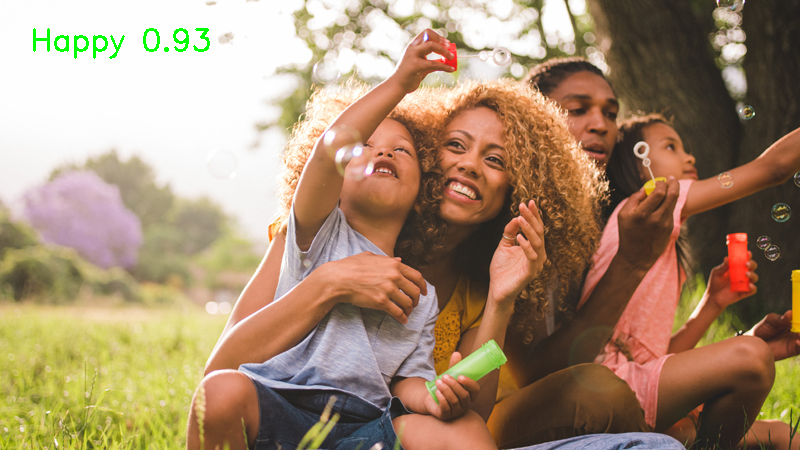


image 1/1 /content/dataset/test/Angry/How-To-Communicate-With-Irrational-And-Angry-People.jpg: 224x224 Angry 0.60, Sad 0.29, Happy 0.11, 6.9ms
Speed: 9.2ms preprocess, 6.9ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
[2] How-To-Communicate-With-Irrational-And-Angry-People.jpg → Angry (0.60)


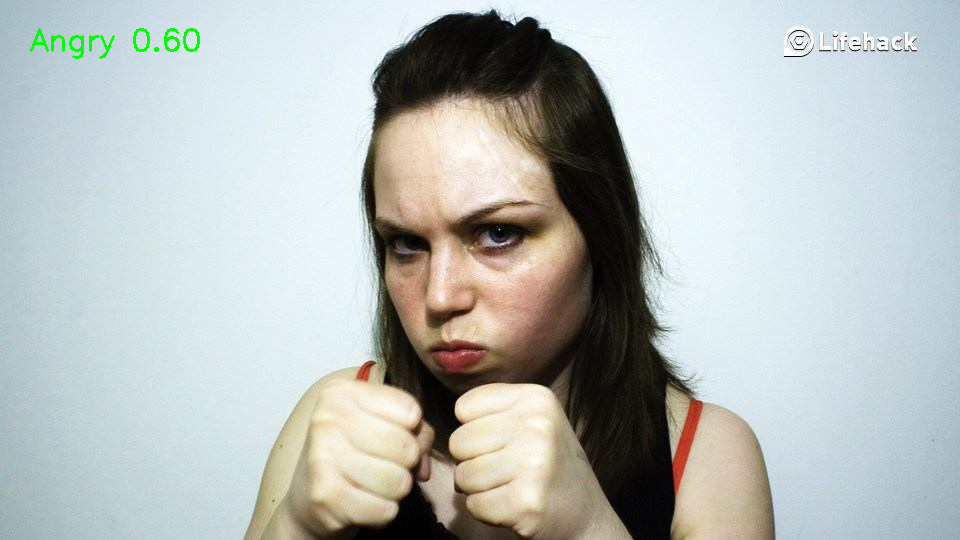


image 1/1 /content/dataset/test/Sad/sue.jpg: 224x224 Sad 0.71, Angry 0.20, Happy 0.09, 5.9ms
Speed: 23.4ms preprocess, 5.9ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
[3] sue.jpg → Sad (0.71)


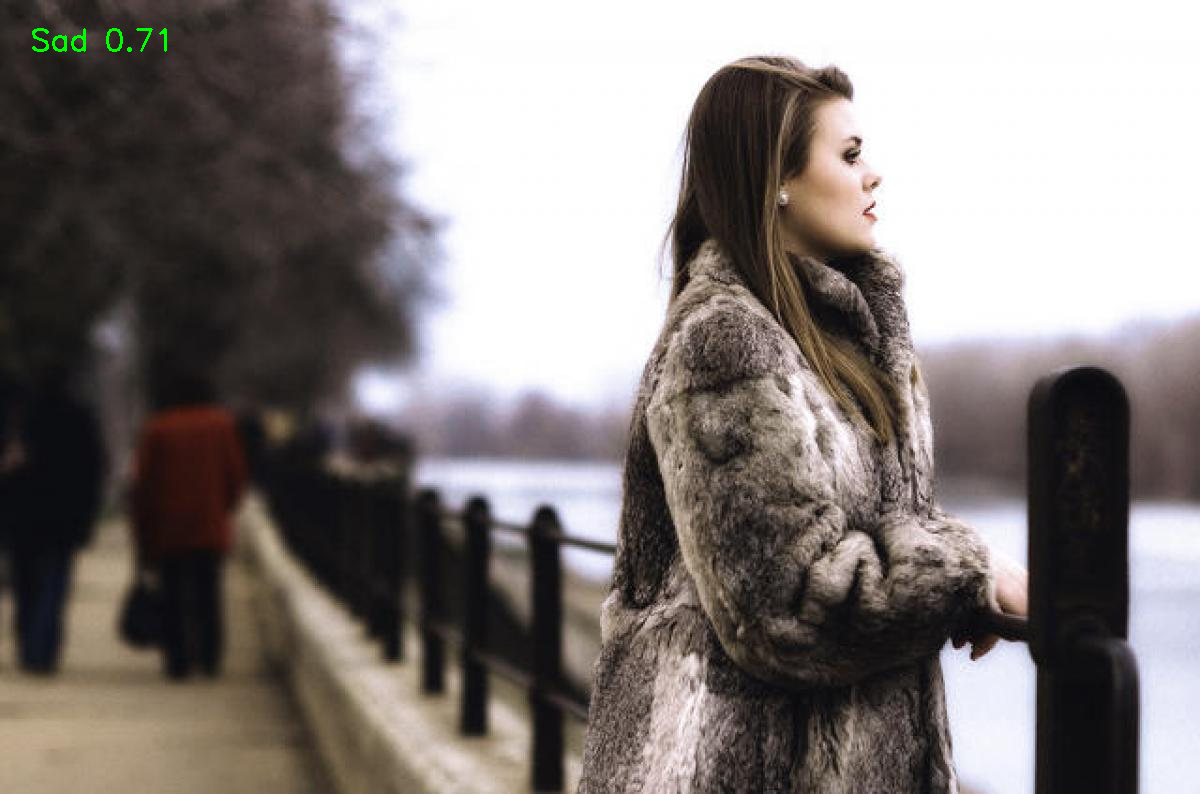


image 1/1 /content/dataset/test/Angry/family-three-mother-father-son-260nw-1598501143.jpg: 224x224 Angry 0.60, Happy 0.32, Sad 0.07, 4.8ms
Speed: 5.1ms preprocess, 4.8ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
[4] family-three-mother-father-son-260nw-1598501143.jpg → Angry (0.60)


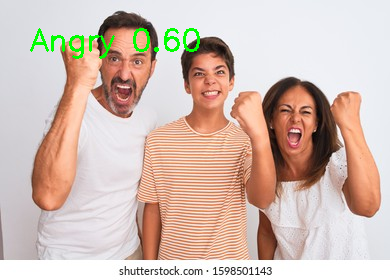


image 1/1 /content/dataset/test/Angry/439-4398363_angry-man-png-pictures-angry-person-png-transparent.png: 224x224 Angry 0.49, Sad 0.32, Happy 0.19, 4.1ms
Speed: 13.8ms preprocess, 4.1ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
[5] 439-4398363_angry-man-png-pictures-angry-person-png-transparent.png → Angry (0.49)


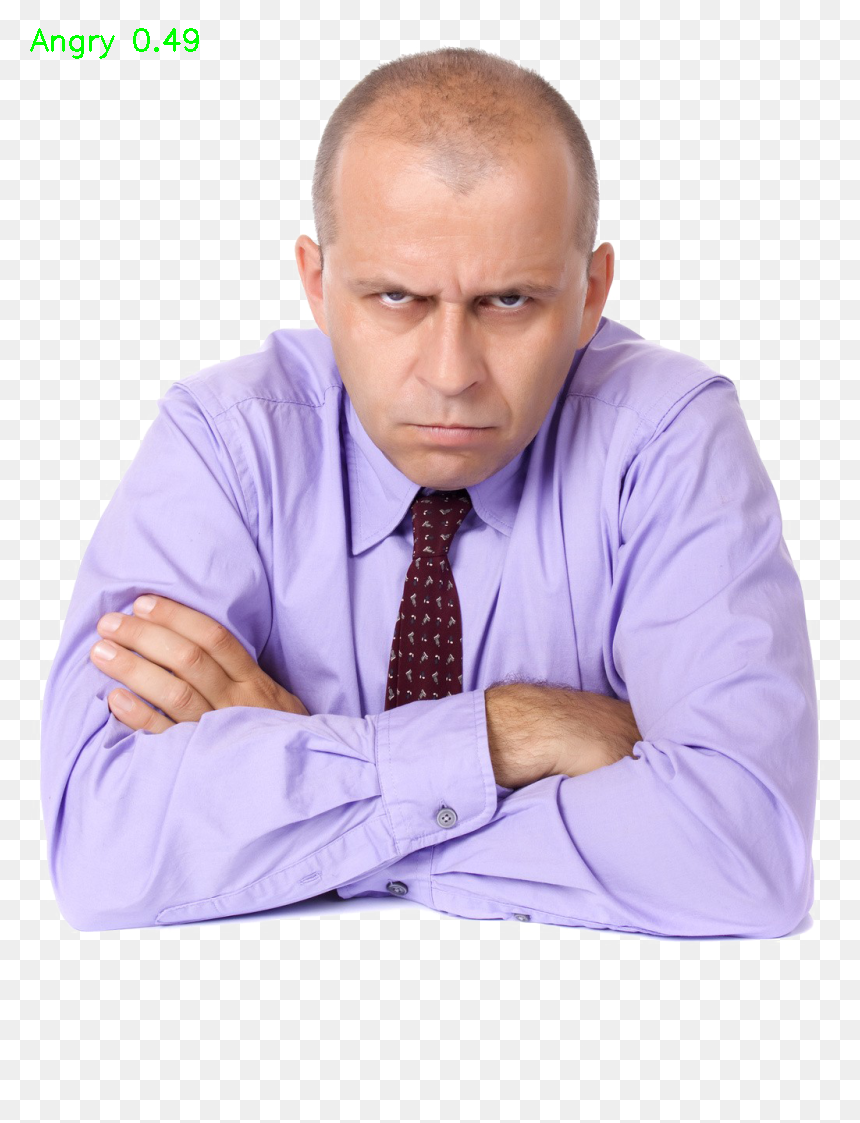

In [1]:
# =========================
# 1.解壓縮face_data.zip
# =========================
import zipfile
import os

zip_path = "/content/face_data.zip" #查看zip檔名是否正確
extract_path = "/content/face_data" #查看資料夾路徑是否正確

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("解壓完成")

# =========================
# 2.安裝套件
# =========================
!pip install ultralytics

# =========================
# 3.切分資料（train/val/test = 8:1:1）
# =========================
import shutil
import random

# 解壓後
base_dir = "/content/face_data/face_data"
output_dir = "/content/dataset"

classes = ["Happy", "Sad", "Angry"]

for cls in classes:
    img_dir = os.path.join(base_dir, cls)

    images = os.listdir(img_dir)
    random.shuffle(images)

    total = len(images)

    train_split = int(total * 0.8)
    val_split = int(total * 0.9)

    train_imgs = images[:train_split]
    val_imgs = images[train_split:val_split]
    test_imgs = images[val_split:]

    for split_name, split_data in [
        ("train", train_imgs),
        ("val", val_imgs),
        ("test", test_imgs)
    ]:
        save_dir = os.path.join(output_dir, split_name, cls)
        os.makedirs(save_dir, exist_ok=True)

        for img in split_data:
            shutil.copy(
                os.path.join(img_dir, img),
                os.path.join(save_dir, img)
            )

print("資料切分完成")

# =========================
#  4.訓練 YOLO 情緒分類模型
# =========================
from ultralytics import YOLO

model = YOLO("yolov8n-cls.pt")

model.train(
    data="/content/dataset",
    epochs=10,
    imgsz=224
)

# =========================
#  5.驗證模型（val）
# =========================
metrics = model.val()
print(metrics)

# =========================
# 6.test 前5張預測 + 顯示結果
# =========================
import cv2
import random
from google.colab.patches import cv2_imshow

# 載入最佳模型
model = YOLO("runs/classify/train/weights/best.pt")

test_dir = "/content/dataset/test"

names = ["Angry", "Happy", "Sad"]

# 收集所有圖片
all_images = []

for cls in os.listdir(test_dir):
    cls_path = os.path.join(test_dir, cls)

    for img_name in os.listdir(cls_path):
        all_images.append(os.path.join(cls_path, img_name))

# 圖片隨機打亂（更公平）
random.shuffle(all_images)

# =========================
# 7.顯示前5張結果
# =========================
for i, img_path in enumerate(all_images[:5]):

    results = model(img_path)
    img = cv2.imread(img_path)

    for r in results:
        top1 = r.probs.top1
        conf = r.probs.top1conf
        label = names[top1]

        print(f"[{i+1}] {os.path.basename(img_path)} → {label} ({conf:.2f})")

        cv2.putText(img,
                    f"{label} {conf:.2f}",
                    (30, 50),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1,
                    (0, 255, 0),
                    2)
    cv2_imshow(img)



#程式結束